In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from functions import *

define the Task

In [3]:
### ### use life expectancy and long term unemployment rate to predict the perceived happiness
### (low or high) of inbabitants of a country

Acquire Clean Data

In [4]:
## load the dataset
dataset = pd.read_csv("World_Happiness_Report.csv")

Understand the Data

In [5]:
### inspect first few rows

dataset.head(12)

,id,country,lifeexp,unemployment,happiness
0,0,Albania,77.6,6.09,Low
1,1,Bulgaria,75.0,3.24,Low
2,2,Iran,75.8,2.11,Low
3,3,Ukraine,71.9,1.53,Low
4,4,South Afica,61.8,7.52,Low
5,5,Ukraine,71.9,1.53,Low
6,6,Austria,81.4,1.43,High
7,7,Croatia,77.3,5.53,High
8,8,Denmark,80.7,1.36,High
9,9,Portugal,80.8,4.37,High


Look at the Data Shape

In [6]:
### inspect the Data Shape

dataset.shape

(12, 5)

compute Descriptive Statistics

In [7]:
### inspect descriptive stats

dataset.describe()

,id,lifeexp,unemployment
count,12.000000,12.000000,12.000000
mean,5.500000,75.741667,2.910833
std,3.605551,5.375104,2.434526
min,0.000000,61.800000,0.060000
25%,2.750000,74.225000,1.412500
50%,5.500000,77.200000,1.820000
75%,8.250000,78.375000,4.660000
max,11.000000,81.400000,7.520000


Visualize the Data

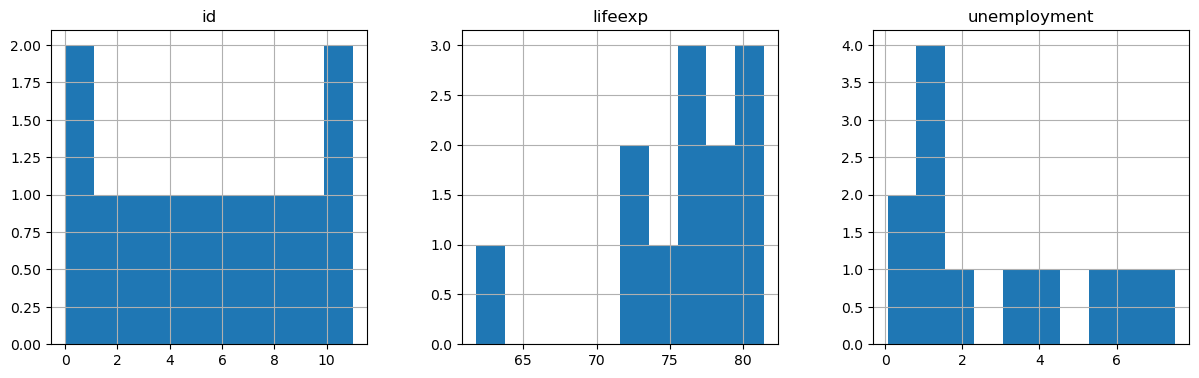

In [18]:
### view univariate histgram
histPlotAll(dataset)

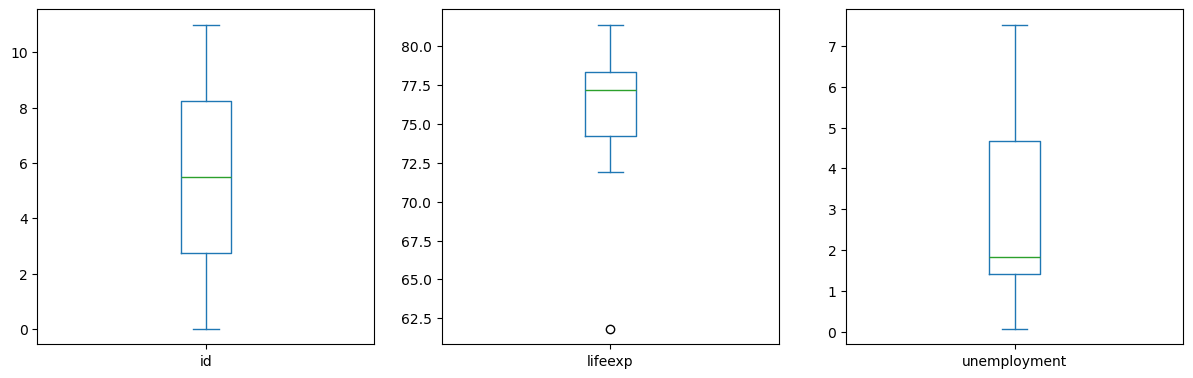

In [19]:
boxPlotAll(dataset)

classCompareplot

Comparative histograms for ['Low' 'High']


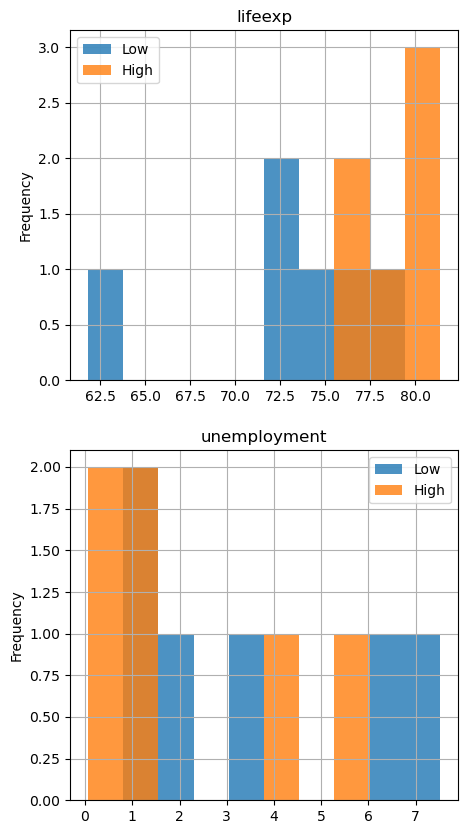

In [21]:
## view class split
classComparePlot(dataset[["happiness","lifeexp", "unemployment"]], "happiness", plotType="hist")

Perpare the Data for supervised machine learning

Select Features and Split into input and Target Features

In [22]:
## we can select happiness as the feature to predict(y) and lifeexp and unemployment as the features
## to make the prediction(x)
## split into input and output features

y = dataset["happiness"]
X = dataset[["lifeexp","unemployment"]]
X.head()

,lifeexp,unemployment
0,77.6,6.09
1,75.0,3.24
2,75.8,2.11
3,71.9,1.53
4,61.8,7.52


In [23]:
y.head()

0    Low
1    Low
2    Low
3    Low
4    Low
Name: happiness, dtype: object

split into Training and Test sets

In [47]:
## Note that i have requested 1/3 of the data to be held back as the test set.
## i have also set the random_state parameter to a seed of seven. this requests a randon 
## sampling of the data but ensure we can always get the same random sampling if we rerun thr experiment

## split into test and training sets

test_size = 0.33
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state = seed)

In [48]:
X_train

,lifeexp,unemployment
0,77.6,6.09
1,75.0,3.24
11,77.6,0.06
8,80.7,1.36
3,71.9,1.53
6,81.4,1.43
9,80.8,4.37
4,61.8,7.52


In [49]:
X_test

,lifeexp,unemployment
7,77.3,5.53
10,77.1,0.16
2,75.8,2.11
5,71.9,1.53


In [50]:
y_train

0      Low
1      Low
11    High
8     High
3      Low
6     High
9     High
4      Low
Name: happiness, dtype: object

In [51]:
y_test

7     High
10    High
2      Low
5      Low
Name: happiness, dtype: object

Select an Algorithm

In [52]:
## select algorithm

model = DecisionTreeClassifier()

Fit The Model To The Data

In [53]:
## fit model to the data

model.fit(X_train,y_train)

DecisionTreeClassifier()

check the model 

In [54]:
## check the model performance on the training data

predictions = model.predict(X_train)
print(accuracy_score(y_train, predictions))

1.0


compute accuracy score

In [55]:
## Evaluate the model on the test data
predictions = model.predict(X_train)

In [56]:
predictions

array(['Low', 'Low', 'High', 'High', 'Low', 'High', 'High', 'Low'],
      dtype=object)

In [57]:
print(accuracy_score(y_test, predictions))

ValueError: Found input variables with inconsistent numbers of samples: [4, 8]

In [58]:
df = X_test.copy()
df["Actual"] = y_test
df["predictions"]= predictions
df

ValueError: Length of values (8) does not match length of index (4)